# 🔗 LCEL — LangChain Expression Language

This notebook explores **LCEL**, LangChain's `|` (pipe) syntax for composing prompts, models, parsers, and custom logic into a single runnable pipeline — and *why* it replaced the older `Chain` classes like `LLMChain`.

---

## 🧭 What You'll Build

1. **The Legacy Way** — `PromptTemplate` + `LLMChain`
2. **The LCEL Way** — the same pipeline as `prompt | llm | output_parser`
3. **How `|` Actually Works** — building a minimal `Runnable` class from scratch
4. **Post-Processing an LLM's Output** — extending a chain with custom `RunnableLambda` steps
5. **RAG with Parallel Retrieval** — `RunnableParallel` + `RunnablePassthrough`


## 1. The Legacy Way — `PromptTemplate` + `LLMChain`

Before LCEL existed, prompts, models, and output parsers were wired together using dedicated `Chain` classes like `LLMChain`. This section builds that classic pipeline first, so the LCEL version later feels like a natural simplification.


In [1]:
from langchain_classic import PromptTemplate

prompt_template = "Give me a small report on {topic}"

prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_template
)

### Setting Up the LLM

Configure the Groq-hosted `llama-3.3-70b-versatile` model with `temperature=0.0` for focused, deterministic output.


In [ ]:
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = "put your groq key here "


model="llama-3.3-70b-versatile"

# For normal accurate responses
llm = ChatGroq(temperature=0.0, model=model)

**Test it:** call the LLM directly — the raw output is an `AIMessage` object, not a plain string.


In [3]:
llm_out = llm.invoke("Hello there")
llm_out

AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 37, 'total_tokens': 62, 'completion_time': 0.052229332, 'completion_tokens_details': None, 'prompt_time': 0.003194446, 'prompt_tokens_details': None, 'queue_time': 0.051656838, 'total_time': 0.055423778}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f663b-5888-7101-a3fe-3ef95e7a6a48-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 25, 'total_tokens': 62})

### Parsing the Output

`StrOutputParser` extracts just the plain-text content from an `AIMessage`, discarding the extra metadata.


In [4]:
from langchain_classic.schema.output_parser import StrOutputParser

output_parser = StrOutputParser()

Apply the parser to the raw LLM output to get a clean string.


In [5]:
out = output_parser.invoke(llm_out)
out

"Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?"

### Wiring It Together: `LLMChain`

`LLMChain` bundles the prompt, the LLM, and the output parser into a single legacy `Chain` object.


In [6]:
from langchain_classic.chains import LLMChain

chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)

C:\Users\BS\AppData\Local\Temp\ipykernel_20928\1812892885.py:3: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(prompt=prompt, llm=llm, output_parser=output_parser)


**Test it:** invoke the chain with just the `topic` value — the prompt template gets filled in automatically.


In [7]:
result = chain.invoke("retrieval augmented generation")
result

{'topic': 'retrieval augmented generation',
 'text': '**Retrieval Augmented Generation: A Report**\n\nRetrieval Augmented Generation (RAG) is a type of natural language processing (NLP) technique that combines the strengths of retrieval-based and generation-based approaches to produce high-quality text outputs. This approach has gained significant attention in recent years due to its ability to generate more accurate, informative, and engaging text.\n\n**Key Components:**\n\n1. **Retrieval Module:** This component is responsible for retrieving relevant information from a large database or knowledge graph. The retrieval module uses a query or prompt to search for relevant documents, passages, or entities.\n2. **Generation Module:** This component takes the retrieved information as input and generates text based on the context, intent, and requirements of the task.\n3. **Augmentation Module:** This component combines the outputs of the retrieval and generation modules to produce the fina

Render the result as Markdown for readability.


In [8]:
from IPython.display import display, Markdown

display(Markdown(result["text"]))

**Retrieval Augmented Generation: A Report**

Retrieval Augmented Generation (RAG) is a type of natural language processing (NLP) technique that combines the strengths of retrieval-based and generation-based approaches to produce high-quality text outputs. This approach has gained significant attention in recent years due to its ability to generate more accurate, informative, and engaging text.

**Key Components:**

1. **Retrieval Module:** This component is responsible for retrieving relevant information from a large database or knowledge graph. The retrieval module uses a query or prompt to search for relevant documents, passages, or entities.
2. **Generation Module:** This component takes the retrieved information as input and generates text based on the context, intent, and requirements of the task.
3. **Augmentation Module:** This component combines the outputs of the retrieval and generation modules to produce the final text output.

**Benefits:**

1. **Improved Accuracy:** RAG can produce more accurate text outputs by leveraging the strengths of both retrieval and generation approaches.
2. **Increased Informative Content:** By retrieving relevant information from a large database, RAG can generate text that is more informative and engaging.
3. **Reduced Hallucination:** RAG can reduce hallucination (i.e., generating text that is not based on actual facts) by relying on retrieved information to generate text.

**Applications:**

1. **Question Answering:** RAG can be used to generate answers to complex questions by retrieving relevant information and generating text based on that information.
2. **Text Summarization:** RAG can be used to generate summaries of long documents by retrieving key points and generating text based on those points.
3. **Chatbots and Conversational AI:** RAG can be used to generate responses to user queries by retrieving relevant information and generating text based on that information.

**Challenges:**

1. **Data Quality:** The quality of the retrieved information can significantly impact the quality of the generated text.
2. **Contextual Understanding:** RAG requires a deep understanding of the context and intent of the task to generate accurate and relevant text.
3. **Scalability:** RAG can be computationally expensive and may require significant resources to scale to large datasets and applications.

**Conclusion:**

Retrieval Augmented Generation is a powerful approach to natural language processing that combines the strengths of retrieval and generation-based approaches. By leveraging the benefits of RAG, developers can build more accurate, informative, and engaging text generation systems. However, RAG also presents several challenges, including data quality, contextual understanding, and scalability. Further research and development are needed to fully realize the potential of RAG and to address the challenges associated with this approach.

## 2. The LCEL Way — Same Pipeline, One Line

LCEL replaces `LLMChain` with the `|` (pipe) operator: `prompt | llm | output_parser`. Same three components, connected directly, with no wrapper class needed.


In [9]:
lcel_chain = prompt | llm | output_parser

**Test it:** the LCEL chain produces the identical result to the `LLMChain` version above.


In [10]:
result = lcel_chain.invoke("retrieval augmented generation")
result

'**Retrieval Augmented Generation: A Report**\n\nRetrieval Augmented Generation (RAG) is a type of natural language processing (NLP) technique that combines the strengths of retrieval-based and generation-based approaches to produce more accurate and informative text. This approach has gained significant attention in recent years due to its potential to improve the performance of various NLP tasks, such as question answering, text summarization, and dialogue generation.\n\n**Key Components:**\n\n1. **Retrieval Module:** This component is responsible for retrieving relevant information from a large corpus of text, such as a knowledge base or a database. The retrieval module uses techniques like keyword extraction, named entity recognition, and semantic search to identify the most relevant information.\n2. **Generation Module:** This component takes the retrieved information as input and generates text based on the context and the task requirements. The generation module uses techniques 

Render as Markdown.


In [11]:
display(Markdown(result))

**Retrieval Augmented Generation: A Report**

Retrieval Augmented Generation (RAG) is a type of natural language processing (NLP) technique that combines the strengths of retrieval-based and generation-based approaches to produce more accurate and informative text. This approach has gained significant attention in recent years due to its potential to improve the performance of various NLP tasks, such as question answering, text summarization, and dialogue generation.

**Key Components:**

1. **Retrieval Module:** This component is responsible for retrieving relevant information from a large corpus of text, such as a knowledge base or a database. The retrieval module uses techniques like keyword extraction, named entity recognition, and semantic search to identify the most relevant information.
2. **Generation Module:** This component takes the retrieved information as input and generates text based on the context and the task requirements. The generation module uses techniques like language modeling, machine translation, and text summarization to produce coherent and fluent text.

**How RAG Works:**

1. The retrieval module retrieves a set of relevant documents or passages from the corpus based on the input query or prompt.
2. The generation module takes the retrieved documents as input and generates text based on the context and the task requirements.
3. The generated text is then post-processed to ensure coherence, fluency, and accuracy.

**Advantages:**

1. **Improved Accuracy:** RAG can produce more accurate text by leveraging the strengths of both retrieval-based and generation-based approaches.
2. **Increased Contextual Understanding:** RAG can capture complex contextual relationships between entities and concepts, leading to more informative and relevant text.
3. **Flexibility:** RAG can be applied to a wide range of NLP tasks, including question answering, text summarization, and dialogue generation.

**Challenges and Future Directions:**

1. **Scalability:** RAG requires large amounts of computational resources and data to train and fine-tune the models.
2. **Evaluation Metrics:** Developing effective evaluation metrics to measure the performance of RAG models is a challenging task.
3. **Explainability:** RAG models can be complex and difficult to interpret, making it challenging to understand the decision-making process.

**Conclusion:**

Retrieval Augmented Generation is a powerful technique that has the potential to revolutionize the field of natural language processing. By combining the strengths of retrieval-based and generation-based approaches, RAG can produce more accurate, informative, and contextually relevant text. However, there are still challenges to be addressed, such as scalability, evaluation metrics, and explainability. Further research is needed to fully explore the potential of RAG and to develop more effective and efficient models.

## 3. How Does `|` Actually Work?

To understand LCEL's pipe syntax, build a minimal `Runnable` class from scratch: it wraps a function and overloads Python's `__or__` operator (`|`) so that `a | b` returns a new `Runnable` chaining `a`'s output into `b`'s input.


In [12]:
class Runnable:
    def __init__(self, func):
        self.func = func
    def __or__(self, other):
        def chained_func(*args, **kwargs):
            return other.invoke(self.func(*args, **kwargs))
        return Runnable(chained_func)
    def invoke(self, *args, **kwargs):
        return self.func(*args, **kwargs)

Define a few simple functions to chain together.


In [13]:
def add_five(x):
    return x+5

def sub_five(x):
    return x-5

def mul_five(x):
    return x*5

Wrap each function in the custom `Runnable` class.


In [14]:
add_five_runnable = Runnable(add_five)
sub_five_runnable = Runnable(sub_five)
mul_five_runnable = Runnable(mul_five)

Chain them by calling `.__or__()` explicitly — this is exactly what the `|` operator does under the hood.


In [15]:
chain = (add_five_runnable).__or__(sub_five_runnable).__or__(mul_five_runnable)

chain.invoke(3)

15

The same chain, written naturally with the `|` operator — identical result.


In [16]:
chain = add_five_runnable | sub_five_runnable | mul_five_runnable

chain.invoke(3)

15

### LangChain's Real `RunnableLambda`

LangChain ships its own version of this same idea: `RunnableLambda` wraps any plain Python function so it can be piped (`|`) together with prompts, LLMs, parsers, or other runnables.


In [17]:
from langchain_core.runnables import RunnableLambda

add_five_runnable = RunnableLambda(add_five)
sub_five_runnable = RunnableLambda(sub_five)
mul_five_runnable = RunnableLambda(mul_five)

**Test it:** confirm `RunnableLambda`-wrapped functions chain and behave exactly like the custom `Runnable` class above.


In [18]:
lcel_chain = add_five_runnable | sub_five_runnable | mul_five_runnable

lcel_chain.invoke(3)

15

## 4. Post-Processing an LLM's Output

LCEL chains aren't limited to prompt → LLM → parser — any number of extra processing steps can be appended, as long as each one is wrapped in a `Runnable`.


In [19]:
prompt_str = "give me a small report about {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_str
)

Build the base chain: prompt → LLM → string output.


In [20]:
chain = prompt | llm | output_parser

**Test it:** run the base chain on a topic and render the raw report.


In [21]:
result = chain.invoke("AI")
display(Markdown(result))

**Artificial Intelligence (AI) Report**

**Introduction:**
Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. AI has been rapidly advancing in recent years, transforming various industries and aspects of our lives.

**Key Developments:**

1. **Machine Learning (ML):** A subset of AI that enables systems to learn from data and improve their performance over time. ML has been widely adopted in applications such as image recognition, natural language processing, and predictive analytics.
2. **Deep Learning:** A type of ML that uses neural networks to analyze complex data, such as images, speech, and text. Deep learning has achieved state-of-the-art results in various applications, including computer vision, speech recognition, and language translation.
3. **Natural Language Processing (NLP):** AI-powered systems that can understand, generate, and process human language. NLP has improved significantly, enabling applications such as chatbots, virtual assistants, and language translation.

**Applications:**

1. **Virtual Assistants:** AI-powered virtual assistants, such as Siri, Alexa, and Google Assistant, have become increasingly popular, allowing users to interact with devices using voice commands.
2. **Image Recognition:** AI-powered image recognition systems are used in applications such as facial recognition, object detection, and self-driving cars.
3. **Healthcare:** AI is being used in healthcare to analyze medical images, diagnose diseases, and develop personalized treatment plans.

**Challenges and Future Directions:**

1. **Ethics and Bias:** AI systems can perpetuate biases and raise ethical concerns, such as privacy and job displacement.
2. **Explainability:** AI systems can be complex and difficult to interpret, making it challenging to understand their decision-making processes.
3. **Future Developments:** AI is expected to continue advancing, with potential applications in areas such as robotics, autonomous vehicles, and education.

**Conclusion:**
AI has made significant progress in recent years, transforming various industries and aspects of our lives. While there are challenges and concerns associated with AI, its potential benefits and applications are vast and exciting. As AI continues to evolve, it is essential to address the challenges and ensure that its development is aligned with human values and societal needs.

Define two custom post-processing functions: one strips the report down to just its first fact, the other does a word find-and-replace.


In [22]:
def extract_fact(x):
    if "\n\n" in x:
        return "\n".join(x.split("\n\n")[1:])
    else:
        return x

old_word = "AI"
new_word = "SKY"

def replace_word(x):
    return x.replace(old_word, new_word)

Wrap both functions in `RunnableLambda` so they can be piped like any other step.


In [23]:
extract_fact_runnable = RunnableLambda(extract_fact)
replace_word_runnable = RunnableLambda(replace_word)

**Extend the chain:** append both post-processing steps after the output parser — the pipeline is now prompt → LLM → parser → extract fact → replace word.


In [24]:
chain = prompt | llm | output_parser | extract_fact_runnable | replace_word_runnable

**Test it:** run the full extended chain and see both transformations applied to the final output.


In [25]:
result = chain.invoke("retrieval augmented generation")
display(Markdown(result))

Retrieval-Augmented Generation (RAG) is a novel approach in Natural Language Processing (NLP) that combines the strengths of retrieval-based and generation-based models. This paradigm has gained significant attention in recent years due to its ability to generate high-quality, informative, and context-specific text.
**Key Components:**
1. **Retrieval Module:** This component is responsible for retrieving relevant information from a large corpus of text, such as a knowledge base or a database. The retrieval module uses techniques like semantic search, entity recognition, and question answering to identify the most relevant information.
2. **Generation Module:** This component takes the retrieved information as input and generates text based on the context, intent, and requirements of the task. The generation module uses techniques like language modeling, machine translation, and text summarization to produce coherent and fluent text.
**How RAG Works:**
1. The retrieval module retrieves relevant information from the corpus based on the input prompt or query.
2. The retrieved information is then passed to the generation module, which uses this information to generate text.
3. The generated text is then refined and polished using various techniques like language modeling and post-processing.
**Advantages:**
1. **Improved Contextual Understanding:** RAG models can capture complex contextual relationships between entities, events, and concepts, leading to more accurate and informative text generation.
2. **Increased Efficiency:** By leveraging the strengths of both retrieval and generation models, RAG can reduce the computational requirements and improve the overall efficiency of text generation tasks.
3. **Enhanced Flexibility:** RAG models can be fine-tuned for various NLP tasks, such as question answering, text summarization, and dialogue generation.
**Applications:**
1. **Chatbots and Virtual Assistants:** RAG can be used to generate more informative and context-specific responses in chatbots and virtual assistants.
2. **Content Generation:** RAG can be used to generate high-quality content, such as articles, blog posts, and product descriptions.
3. **Language Translation:** RAG can be used to improve machine translation systems by incorporating retrieval-based approaches.
**Conclusion:**
Retrieval-Augmented Generation is a promising approach in NLP that combines the strengths of retrieval and generation models. By leveraging the power of both paradigms, RAG models can generate high-quality, informative, and context-specific text, making them suitable for a wide range of applications. As research in this area continues to evolve, we can expect to see significant improvements in the field of NLP and its applications.

## 5. RAG with Parallel Retrieval

Set up separate vector stores, each holding different pieces of information, using free local `HuggingFaceEmbeddings` for embedding the text.


In [26]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import DocArrayInMemorySearch

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vecstore_a = DocArrayInMemorySearch.from_texts(
    [
        "half the info is here",
        "DeepSeek-V3 was released in December 2024"
    ],
    embedding=embedding
)

vecstore_b = DocArrayInMemorySearch.from_texts(
    [
        "the other half of the info is here",
        "the DeepSeek-V3 LLM is a mixture of experts model with 671B parameters"
    ],
    embedding=embedding
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Parallel retrieval architecture** — both vector stores are queried at the same time, and their results are merged into the prompt's context before the LLM ever sees the question.

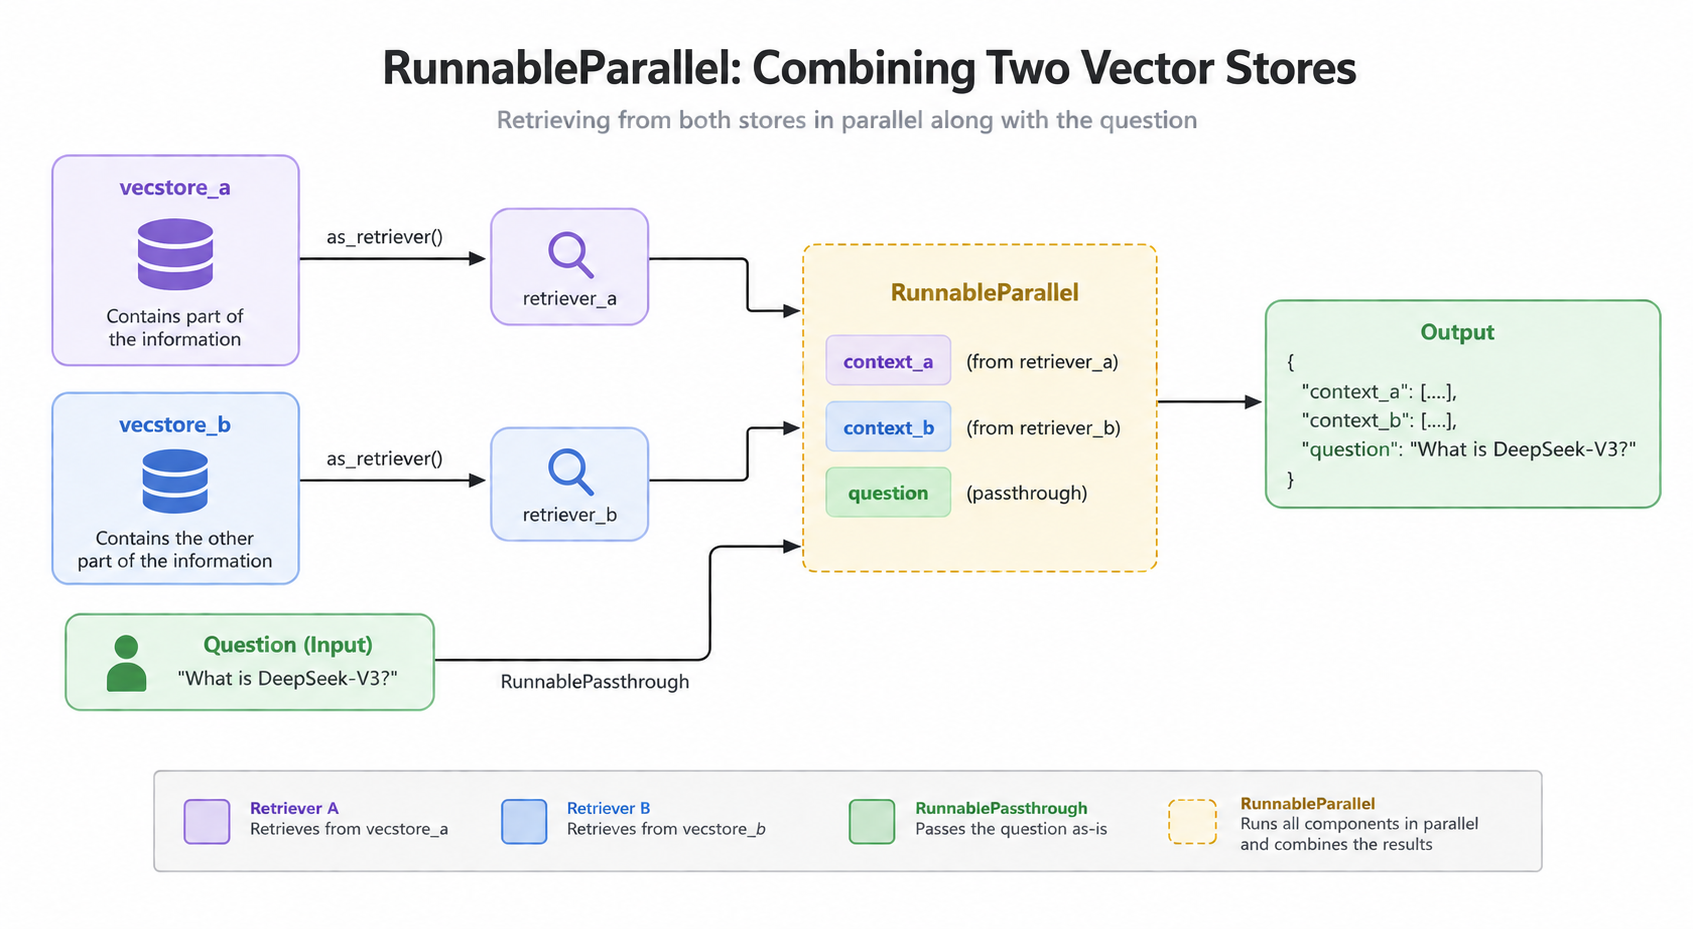

### Building the RAG Prompt

The system prompt expects two context slots (`context_a`, `context_b`) that will be filled by parallel retrieval, plus the user's `question`.


In [27]:
prompt_str = """Using the context provided, answer the user's question.
Context:
{context_a}
{context_b}
"""

Build the chat prompt using `SystemMessagePromptTemplate` and `HumanMessagePromptTemplate`, matching the placeholders above.


In [28]:
from langchain_classic.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(prompt_str),
    HumanMessagePromptTemplate.from_template("{question}")
])

### Retrieving in Parallel

`RunnableParallel` runs multiple runnables **simultaneously** on the same input — here, both retrievers plus `RunnablePassthrough` (which forwards the original question unchanged) all execute at once, producing a dict with `context_a`, `context_b`, and `question`.


In [29]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever_a = vecstore_a.as_retriever()
retriever_b = vecstore_b.as_retriever()

retrieval = RunnableParallel(
    {
        "context_a": retriever_a, "context_b": retriever_b, "question": RunnablePassthrough()
    }
)

### Assembling the Full RAG Chain

Chain everything together: parallel retrieval → prompt → LLM → output parser.


In [30]:
chain = retrieval|prompt | llm | output_parser

**Test it:** ask a question that requires combining information split across both vector stores.


In [31]:
result = chain.invoke(
    str("what architecture does the model DeepSeek released in december use?")
)
result

'The DeepSeek-V3 model, released in December 2024, uses a Mixture of Experts (MoE) architecture with 671B parameters.'